# FracAtlas fracture classifier

In [1]:
from pathlib import Path
import json
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")
import math
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

# Allow TensorFlow to grow GPU memory as needed instead of reserving a fixed block.
_available_gpus = tf.config.list_physical_devices('GPU')
for _gpu in _available_gpus:
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except RuntimeError:
        pass
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# This works whether Jupyter starts in ai-service/ or ai-service/notebooks/.
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
SERVICE_DIR = next(path for path in candidates if (path / 'app').is_dir() and (path / 'requirements.txt').exists())
PROJECT_DIR = SERVICE_DIR.parent
sys.path.insert(0, str(SERVICE_DIR))

from app.config import ARTIFACT_DIR, IMAGE_SIZE, MODEL_VERSION, SEED
from app.data import load_manifest
from app.labels import CLASS_NAMES
from app.model import build_model

DATASET_CSV = PROJECT_DIR / 'Dataset' / 'FracAtlas' / 'dataset.csv'
IMAGE_DIR = PROJECT_DIR / 'Dataset' / 'FracAtlas' / 'images'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
tf.keras.utils.set_random_seed(SEED)
print('Service:', SERVICE_DIR)
print('Dataset:', DATASET_CSV)
print('TensorFlow:', tf.__version__)
print('Python:', sys.executable)
GPUS = tf.config.list_physical_devices('GPU')
print('GPUs:', GPUS)
if not GPUS:
    raise RuntimeError('GPU kernel not selected. Choose Python (FractureCare AI GPU) before training.')

I0000 00:00:1787783940.358405     385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787783943.147734     385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Service: /mnt/c/Users/Rushd/OneDrive - wslqd/Documents/Uni Documents/ICBT/Development Project Final Year/Final Documents/fracturecare-prototype/ai-service
Dataset: /mnt/c/Users/Rushd/OneDrive - wslqd/Documents/Uni Documents/ICBT/Development Project Final Year/Final Documents/fracturecare-prototype/Dataset/FracAtlas/dataset.csv
TensorFlow: 2.21.0
Python: /home/rushd/fracturecare-ai-venv/bin/python
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1787783944.544397     385 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 1. Load and label the dataset

FracAtlas provides `fractured` and `fracture_count`. The application contract groups those fields into three classes.

In [2]:
frame = load_manifest()

print(f'Usable images: {len(frame):,}')
display(frame[['image_id', 'label', 'path']].head())
display(frame['label'].value_counts().reindex(CLASS_NAMES).rename('count').to_frame())

W0000 00:00:1787783974.750104     385 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
E0000 00:00:1787784010.157448     385 jpeg_mem.cc:331] Premature end of JPEG data. Stopped at line 414/454
W0000 00:00:1787784010.157551     385 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: jpeg::Uncompress failed. Invalid JPEG data or crop window.
E0000 00:00:1787784010.163152     385 jpeg_mem.cc:331] Premature end of JPEG data. Stopped at line 398/454
W0000 00:00:1787784010.163200     385 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: jpeg::Uncompress failed. Invalid JPEG data or crop window.
E0000 00:00:1787784010.168887     385 jpeg_mem.cc:331] Premature end of JPEG data. Stopped at line 446/454
E0000 00:00:1787784010.239716     385 jpeg_mem.cc:331] Premature end of JPEG data

Usable images: 4,024


/tmp/ipykernel_385/3847161513.py:1: RuntimeWarning: Skipped 59 unreadable image file(s) from the manifest.
  frame = load_manifest()


,image_id,label,path
0,IMG0000000.jpg,NO_FRACTURE,/mnt/c/Users/Rushd/OneDrive - wslqd/Documents/...
1,IMG0000001.jpg,NO_FRACTURE,/mnt/c/Users/Rushd/OneDrive - wslqd/Documents/...
2,IMG0000002.jpg,NO_FRACTURE,/mnt/c/Users/Rushd/OneDrive - wslqd/Documents/...
3,IMG0000003.jpg,NO_FRACTURE,/mnt/c/Users/Rushd/OneDrive - wslqd/Documents/...
4,IMG0000004.jpg,NO_FRACTURE,/mnt/c/Users/Rushd/OneDrive - wslqd/Documents/...


,count
label,
NO_FRACTURE,3307
ONE_FRACTURE,546
MULTIPLE_FRACTURES,171


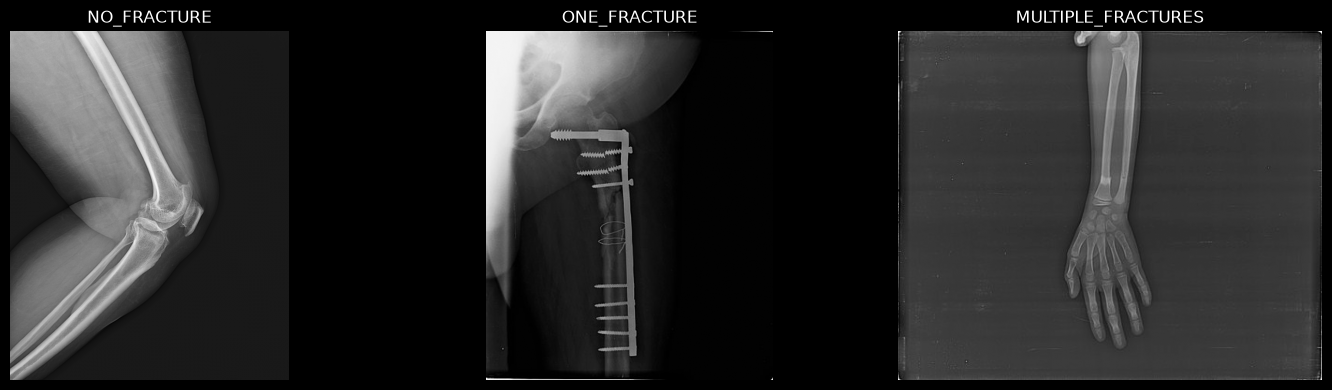

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, class_name in zip(axes, CLASS_NAMES):
    subset = frame[frame['label'] == class_name]
    if subset.empty:
        axis.text(0.5, 0.5, 'No images found', ha='center', va='center')
        axis.set_title(class_name)
        axis.axis('off')
        continue
    sample = subset.sample(1, random_state=SEED).iloc[0]
    image = cv2.imread(sample['path'], cv2.IMREAD_GRAYSCALE)
    axis.imshow(image, cmap='gray')
    axis.set_title(class_name)
    axis.axis('off')
plt.tight_layout()
plt.show()

## 2. Create reproducible train, validation and test splits

In [4]:
train, holdout = train_test_split(
    frame, test_size=0.2, random_state=SEED, stratify=frame['label_index']
)
validation, test = train_test_split(
    holdout, test_size=0.5, random_state=SEED, stratify=holdout['label_index']
)

train = train.reset_index(drop=True)
validation = validation.reset_index(drop=True)
test = test.reset_index(drop=True)
print(f'Train: {len(train):,} | validation: {len(validation):,} | test: {len(test):,}')
display(pd.DataFrame({
    'train': train['label'].value_counts().reindex(CLASS_NAMES),
    'validation': validation['label'].value_counts().reindex(CLASS_NAMES),
    'test': test['label'].value_counts().reindex(CLASS_NAMES),
}))

Train: 3,219 | validation: 402 | test: 403


,train,validation,test
label,,,
NO_FRACTURE,2645,331,331
ONE_FRACTURE,437,54,55
MULTIPLE_FRACTURES,137,17,17


## 3. Build the TensorFlow input pipeline

Images are decoded as grayscale X-rays, converted to three channels for the CNN, resized to 224×224 and kept in the 0–255 range. The model performs its own rescaling.

In [5]:
BATCH_SIZE = 32

def make_dataset(dataframe, shuffle=False):
    paths = dataframe['path'].to_numpy()
    labels = dataframe['label_index'].to_numpy(dtype=np.int32)

    def load(path, label):
        image = tf.io.read_file(path)
        image = tf.io.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, IMAGE_SIZE)
        return image, label

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.apply(tf.data.experimental.ignore_errors())
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset = make_dataset(train, shuffle=True).repeat()
validation_dataset = make_dataset(validation).repeat()
test_dataset = make_dataset(test)
TRAIN_STEPS = math.ceil(len(train) / BATCH_SIZE)
VALIDATION_STEPS = math.ceil(len(validation) / BATCH_SIZE)
class_weights_array = compute_class_weight(
    class_weight='balanced', classes=np.arange(len(CLASS_NAMES)), y=train['label_index'].to_numpy()
)
class_weights = {index: float(weight) for index, weight in enumerate(class_weights_array)}
print('Class weights:', class_weights)

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.
Class weights: {0: 0.4056710775047259, 1: 2.4553775743707096, 2: 7.8321167883211675}


## 4. Train the baseline model

You can change the architecture, augmentation, optimizer, epochs or class weighting in this notebook as you develop the model.

In [6]:
model = build_model()
model.summary()

Model: "fracatlas_fracture_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xray (InputLayer)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 110,819 (432.89 KB)

 Trainable params: 110,371 (431.14 KB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
EPOCHS = 20
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        ARTIFACT_DIR / 'fracture_classifier.keras', monitor='val_accuracy', save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6),
]
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    shuffle=False,
    steps_per_epoch=TRAIN_STEPS,
    validation_steps=VALIDATION_STEPS,
)

Epoch 1/20


E0000 00:00:1787784016.369444     385 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/fracatlas_fracture_classifier_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


100/101 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.4316 - loss: 1.1034

W0000 00:00:1787784036.907879     494 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


101/101 ━━━━━━━━━━━━━━━━━━━━ 25s 184ms/step - accuracy: 0.4321 - loss: 1.1092 - val_accuracy: 0.8234 - val_loss: 0.7360 - learning_rate: 0.0010
Epoch 2/20


...

101/101 ━━━━━━━━━━━━━━━━━━━━ 17s 173ms/step - accuracy: 0.5654 - loss: 0.9583 - val_accuracy: 0.7711 - val_loss: 0.7457 - learning_rate: 3.0000e-04
Epoch 8/20
  3/101 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.6146 - loss: 0.6835

W0000 00:00:1787784145.380395     596 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5927 - loss: 0.9401

W0000 00:00:1787784161.266341     494 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


101/101 ━━━━━━━━━━━━━━━━━━━━ 18s 178ms/step - accuracy: 0.5927 - loss: 0.9401 - val_accuracy: 0.6343 - val_loss: 0.9578 - learning_rate: 9.0000e-05


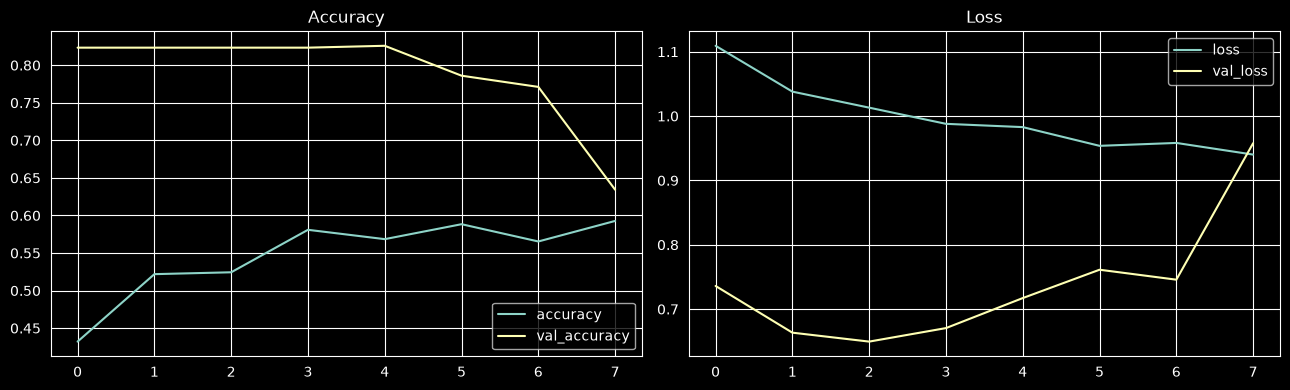

In [8]:
history_frame = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
history_frame[['accuracy', 'val_accuracy']].plot(ax=axes[0], title='Accuracy')
history_frame[['loss', 'val_loss']].plot(ax=axes[1], title='Loss')
plt.tight_layout()
plt.show()

## 5. Evaluate on the held-out test set

/home/rushd/fracturecare-ai-venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Test loss: 0.7263
Test accuracy: 0.8139
                    precision    recall  f1-score   support

       NO_FRACTURE       0.83      0.99      0.90       331
      ONE_FRACTURE       0.14      0.02      0.03        55
MULTIPLE_FRACTURES       0.00      0.00      0.00        17

          accuracy                           0.81       403
         average       0.32      0.34      0.31       403
      weighted avg       0.70      0.81      0.74       403



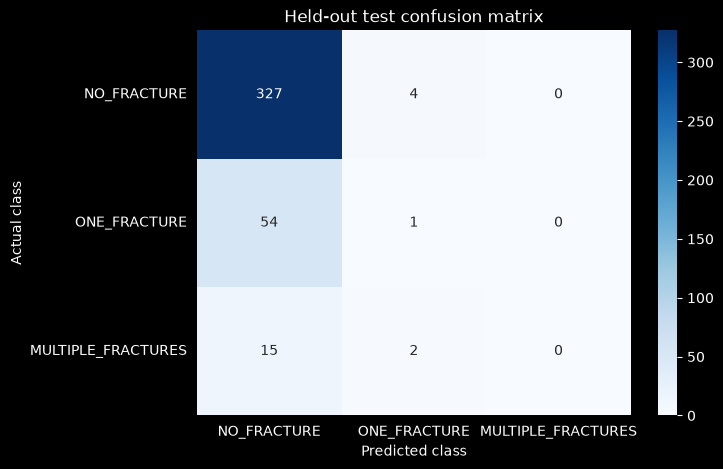

In [9]:
best_model = tf.keras.models.load_model(ARTIFACT_DIR / 'fracture_classifier.keras')
test_loss, test_accuracy = best_model.evaluate(test_dataset, verbose=0)
probabilities = best_model.predict(test_dataset, verbose=0)
predicted = probabilities.argmax(axis=1)
actual = np.concatenate([labels.numpy() for _, labels in test_dataset], axis=0)

print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')
print(classification_report(actual, predicted, target_names=CLASS_NAMES, zero_division=0).replace('macro avg', 'average'))

matrix = confusion_matrix(actual, predicted, labels=np.arange(len(CLASS_NAMES)))
plt.figure(figsize=(7, 5))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.title('Held-out test confusion matrix')
plt.show()

## 6. Save the service metadata

The FastAPI service reads the `.keras` model and this metadata file. Keep them together whenever you change the model.

In [10]:
test.to_csv(ARTIFACT_DIR / 'test_manifest.csv', index=False)
metadata = {
    'modelVersion': MODEL_VERSION,
    'classes': list(CLASS_NAMES),
    'imageSize': list(IMAGE_SIZE),
    'datasetCsv': str(DATASET_CSV),
    'trainCount': int(len(train)),
    'validationCount': int(len(validation)),
    'testCount': int(len(test)),
    'classWeights': class_weights,
    'testLoss': float(test_loss),
    'testAccuracy': float(test_accuracy),
    'epochsCompleted': len(history.history['loss']),
}
(ARTIFACT_DIR / 'model_metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print('Saved artifacts to:', ARTIFACT_DIR)
print(json.dumps(metadata, indent=2))

Saved artifacts to: /mnt/c/Users/Rushd/OneDrive - wslqd/Documents/Uni Documents/ICBT/Development Project Final Year/Final Documents/fracturecare-prototype/ai-service/artifacts
{
  "modelVersion": "fracatlas-cnn-1.0.0",
  "classes": [
    "NO_FRACTURE",
    "ONE_FRACTURE",
    "MULTIPLE_FRACTURES"
  ],
  "imageSize": [
    224,
    224
  ],
  "datasetCsv": "/mnt/c/Users/Rushd/OneDrive - wslqd/Documents/Uni Documents/ICBT/Development Project Final Year/Final Documents/fracturecare-prototype/Dataset/FracAtlas/dataset.csv",
  "trainCount": 3219,
  "validationCount": 402,
  "testCount": 403,
  "classWeights": {
    "0": 0.4056710775047259,
    "1": 2.4553775743707096,
    "2": 7.8321167883211675
  },
  "testLoss": 0.7262753248214722,
  "testAccuracy": 0.8138957619667053,
  "epochsCompleted": 8
}


## 7. Try one image

This uses the same preprocessing as the API endpoint.

In [11]:
def predict_path(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f'Could not read image: {path}')
    image = cv2.resize(image, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    values = best_model.predict(np.expand_dims(image, axis=0), verbose=0)[0]
    return {name: float(values[index]) for index, name in enumerate(CLASS_NAMES)}

sample_path = Path(test.iloc[0]['path'])
print(sample_path.name)
print(predict_path(sample_path))

IMG0002540.jpg
{'NO_FRACTURE': 0.5959630012512207, 'ONE_FRACTURE': 0.32293030619621277, 'MULTIPLE_FRACTURES': 0.08110678195953369}
